## Dataset Demo

The objective this demo is to demonstrate how does the raw data look like, and produce figures for the pre-processing section of the paper.

In [1]:
%reload_ext autoreload
%autoreload 2
import numpy as np
import utils
import seaborn as sea
from dataset_preparation import *
import matplotlib.pyplot as plt

### Step 1. Plot IQ samples from the raw dataset

Note: highlight IQ samples from a single preamble for Step 2.
Note: for this task, we're going to be using a single file from S3 bucket (manually downloaded): 

/mobintel-orbit-dataset/orbit_experiment_aug_8/epoch_2024-08-08_19-19-27/tx{node_node1-11}_rx{node_node1-1+rxFreq_2462e6+rxGain_10+capLen_4+rxSampRate_25e6}.dat

Since frame detection module is implemented in Matlab, for simplicity we will re-set indexes of the first frame:

index_start: 210024<br>
index_end: 210424

/home/smazokha2016/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/smazokha2016/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


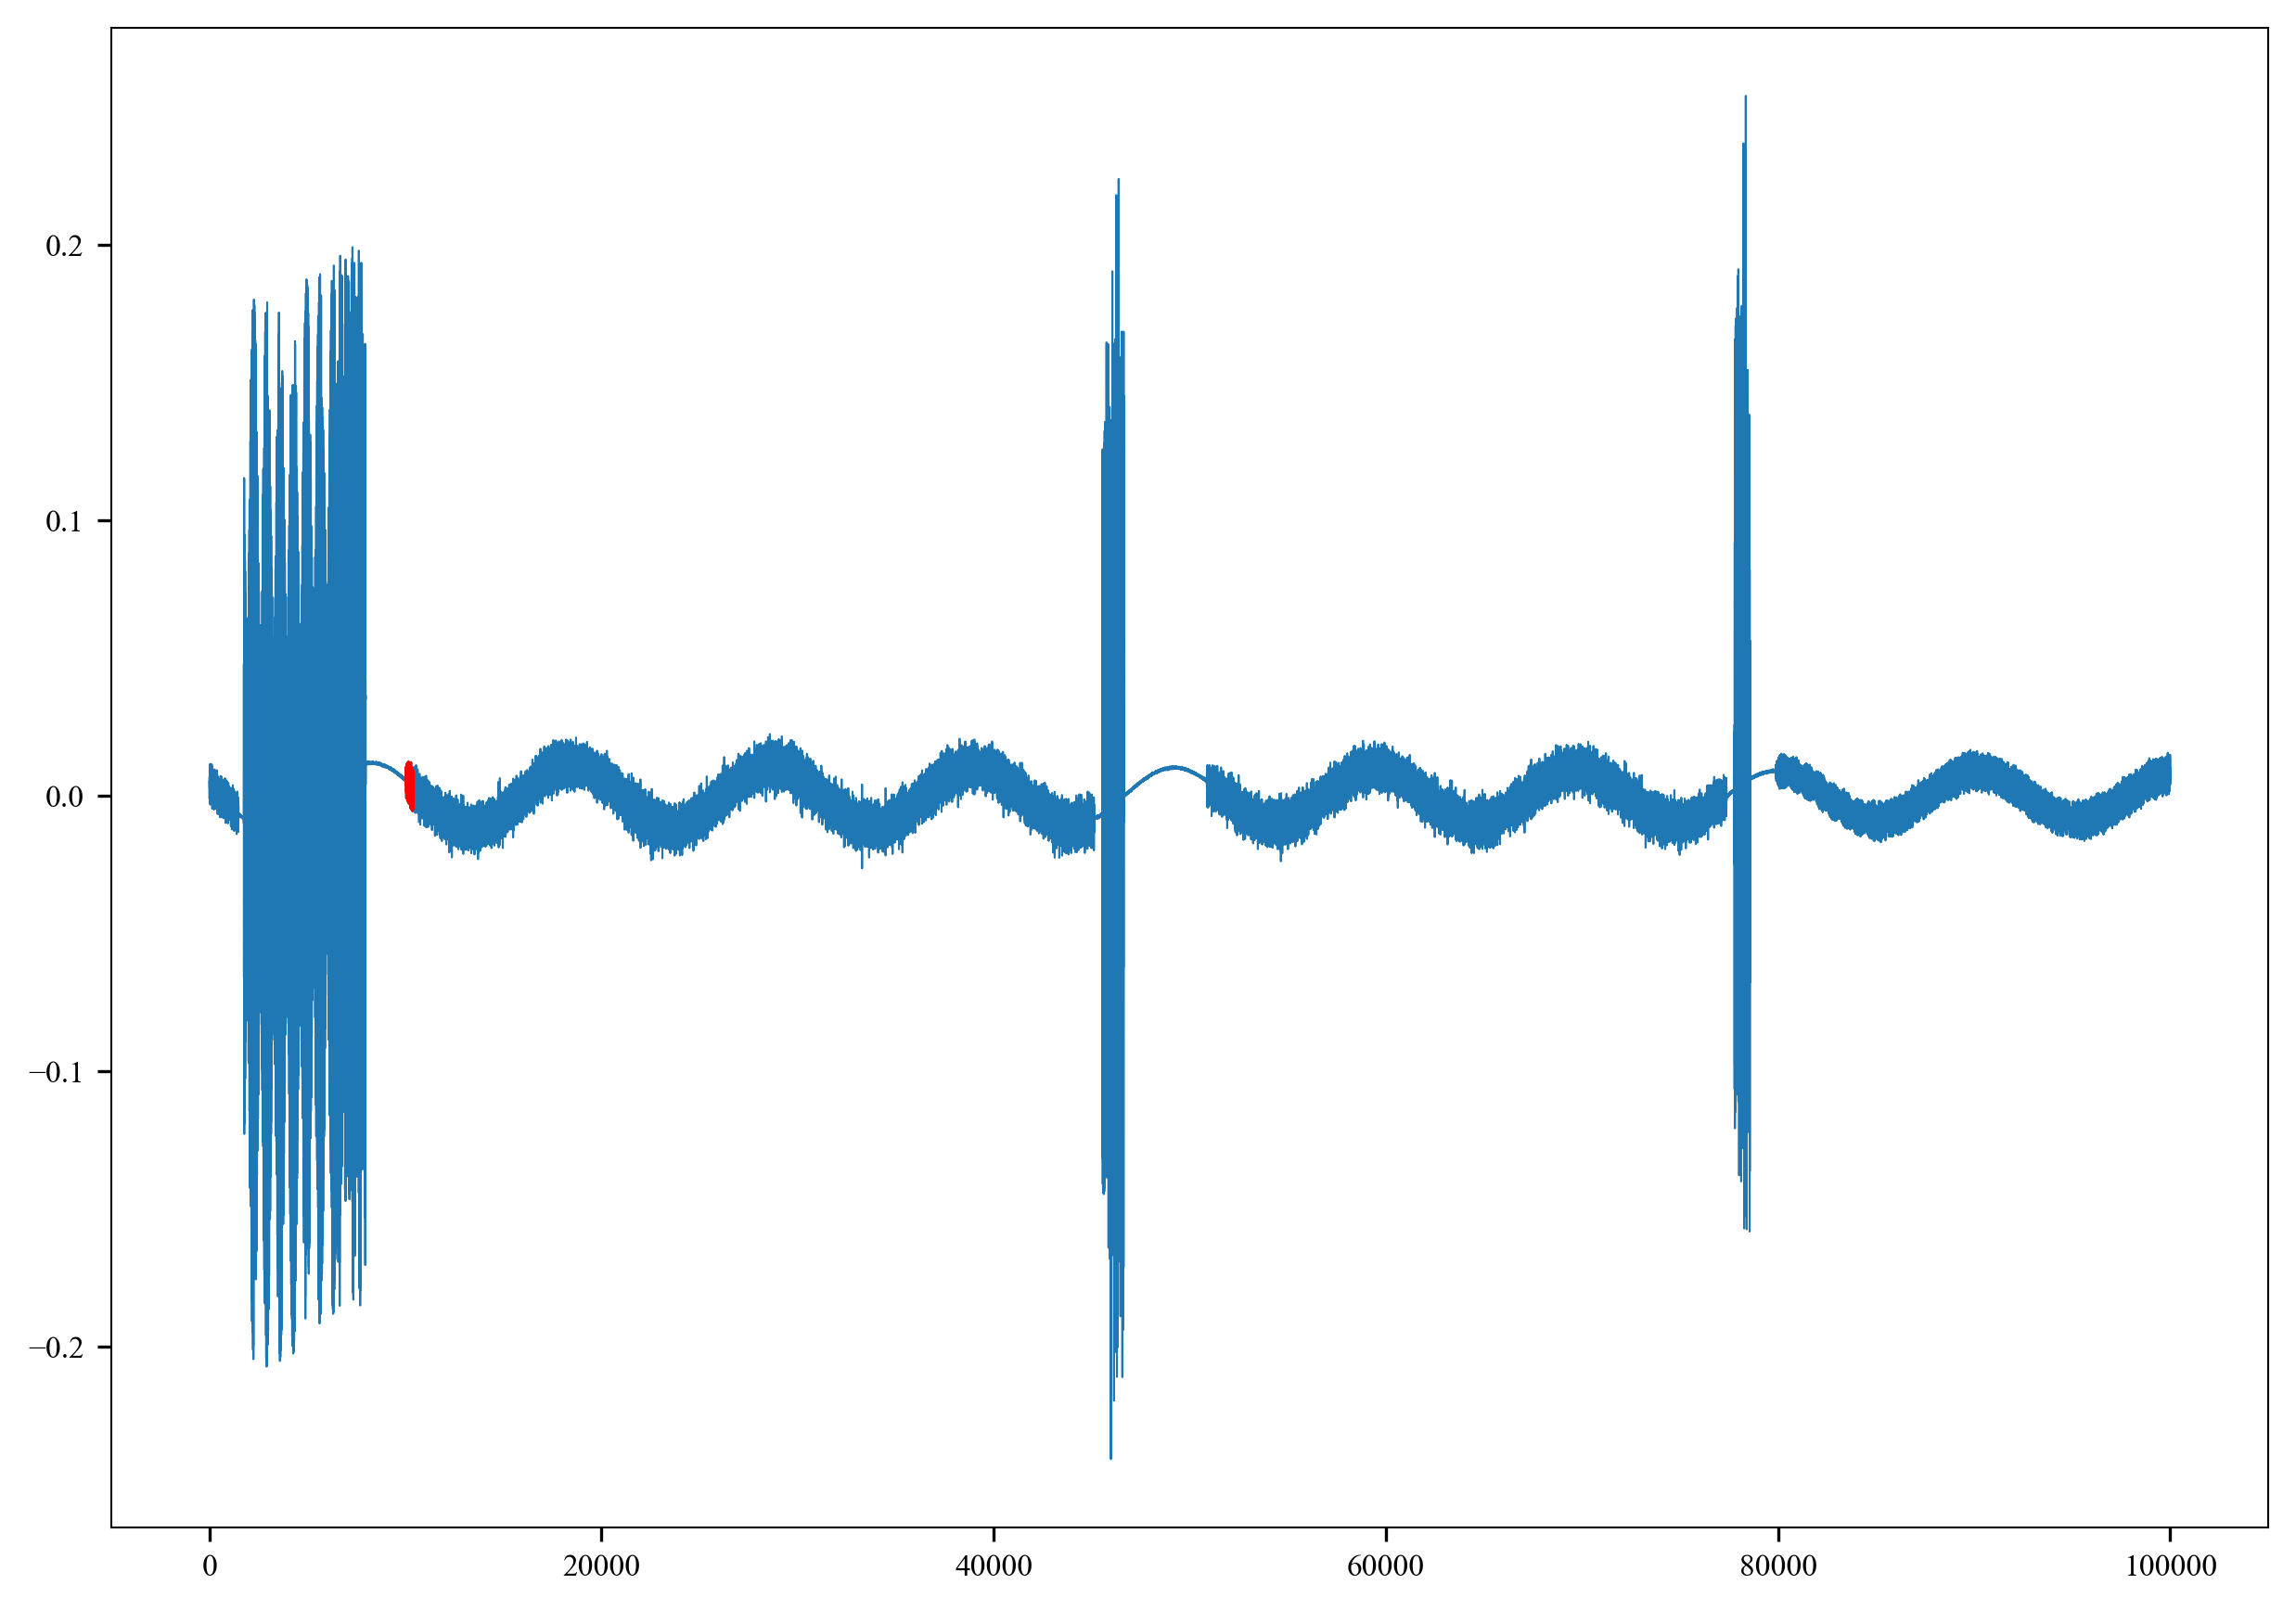

In [10]:
preamble_1_idx = np.arange(210024, 210424)
preamble_2_idx = np.arange(611010, 611410)
preamble_3_idx = np.arange(700000, 700400)

FILE_PATH = '/home/smazokha2016/Desktop/orbit_dataset_v3_aug8/raw_dataset_demo/tx{node_node1-11}_rx{node_node1-1+rxFreq_2462e6+rxGain_10+capLen_4+rxSampRate_25e6}.dat'
iq = utils.read_dat_iq_file(FILE_PATH)

preamble_1 = iq[preamble_1_idx]
preamble_2 = iq[preamble_2_idx]
preamble_3 = iq[preamble_3_idx]

utils.apply_ieee_style()
plt.figure(figsize=(10, 7), dpi=300)
plt.plot(iq[200000:300000])
plt.plot(preamble_1_idx-200000, preamble_1, 'red')

### Step 2. Plot IQ samples of a single preamble



/home/smazokha2016/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/smazokha2016/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


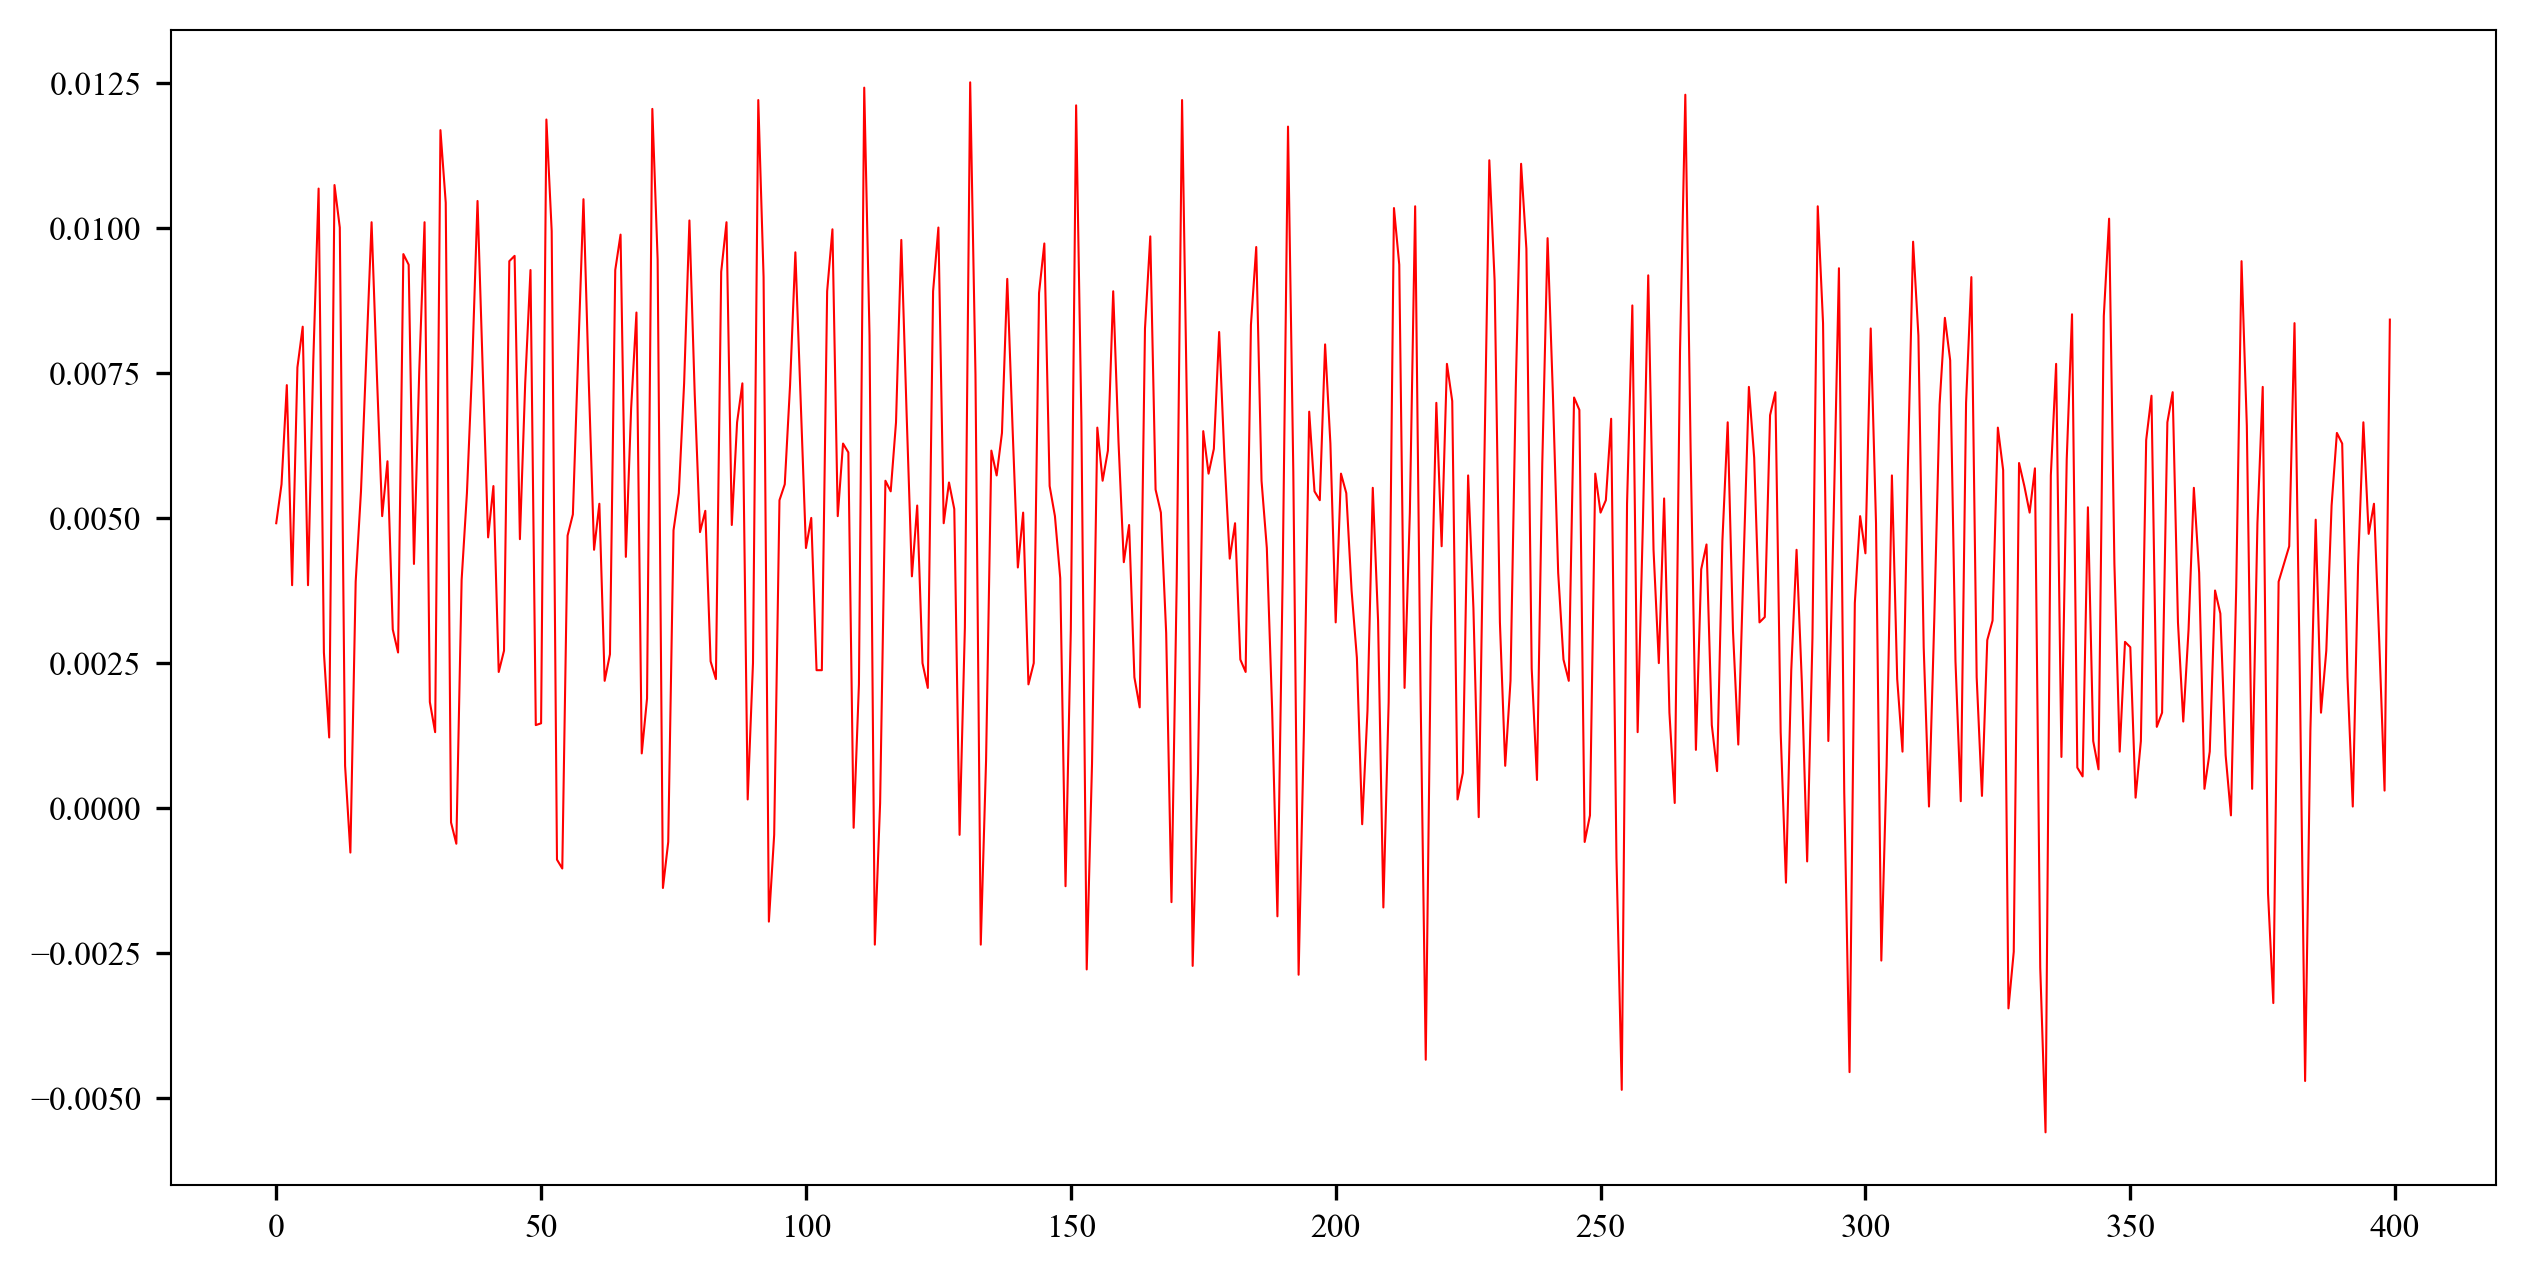

In [11]:
utils.apply_ieee_style()
plt.figure(figsize=(10, 5), dpi=300)
plt.plot(preamble_1, 'red')

### Step 3. Run the pre-processing pipeline and demonstrate STFT result

(50, 15)


<Axes: >

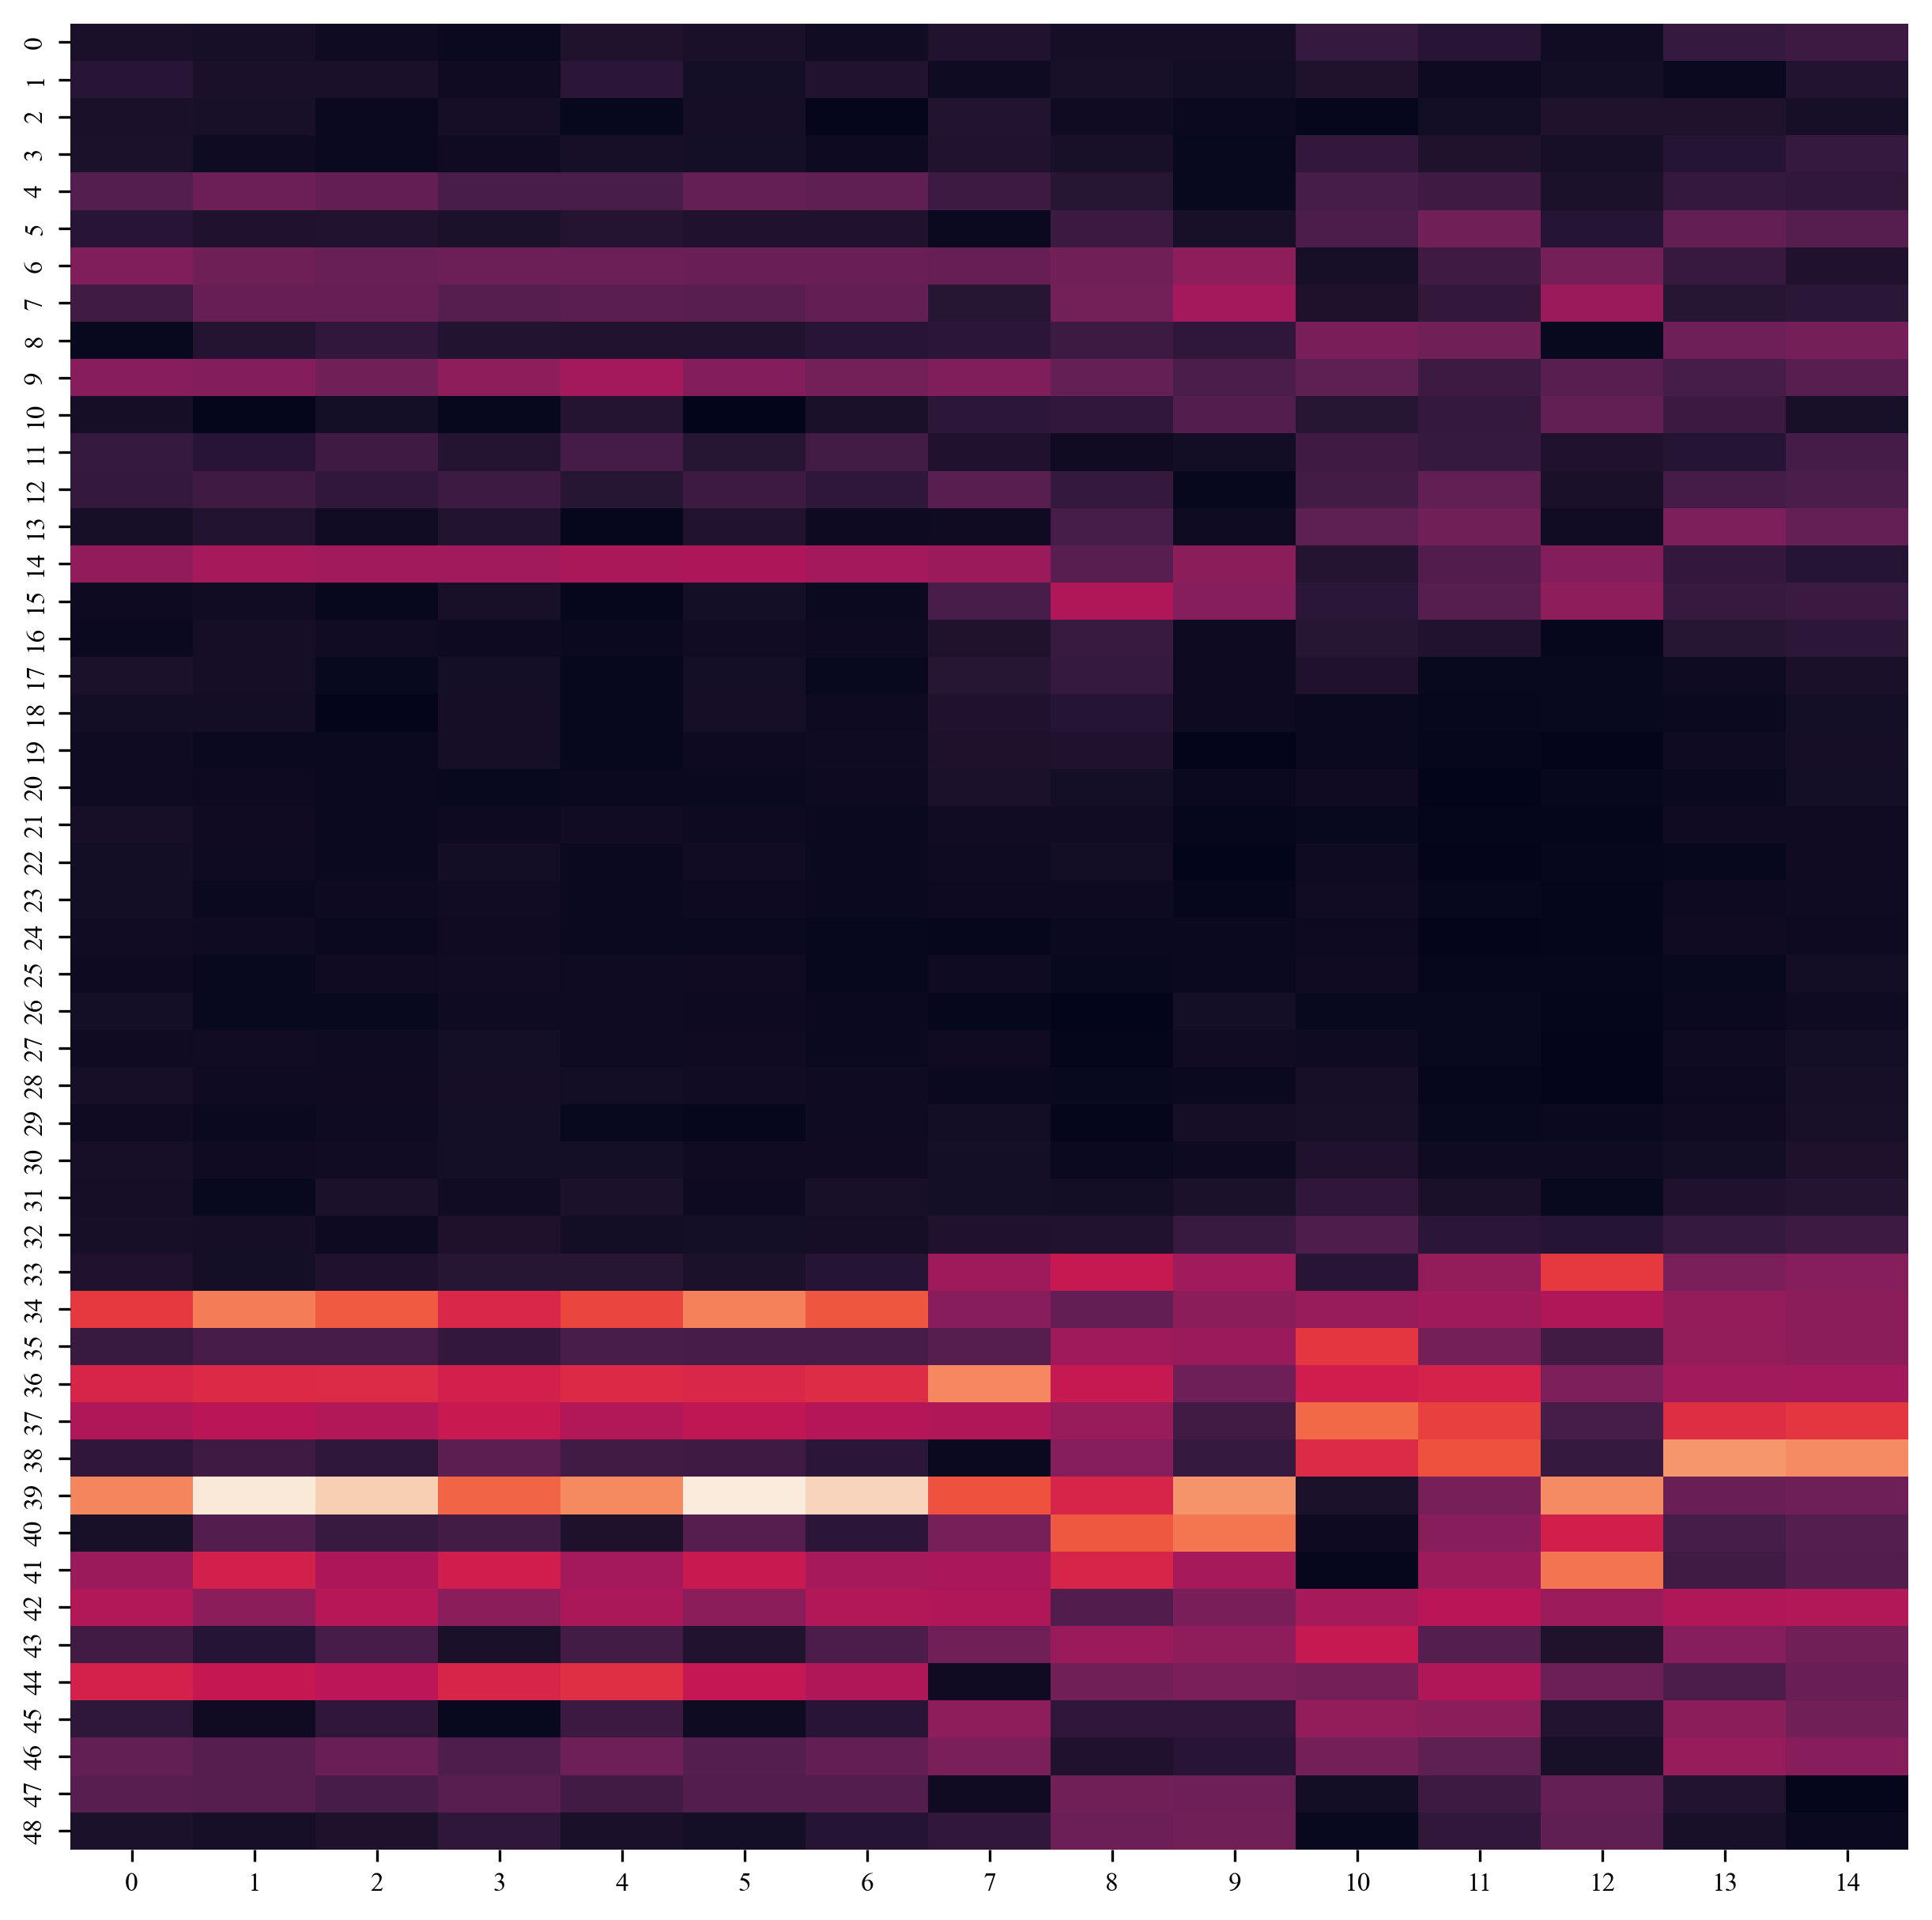

In [16]:
# data = np.array([preamble_1])
data = np.array([preamble_1])

data = ChannelIndSpectrogram()._normalization(data)

win_len = 50
overlap = 25

f, t, spec = signal.stft(data, 
                        window='boxcar', 
                        nperseg=win_len, 
                        noverlap=overlap, 
                        nfft=win_len,
                        return_onesided=False, 
                        padded =False, 
                        boundary=None)

# FFT shift to adjust the central frequency.
spec = np.fft.fftshift(spec, axes=0)

print(spec.squeeze().shape)

plt.figure(figsize=(10, 10), dpi=300)
sea.heatmap(abs(spec.squeeze())[1:, :], cbar=False)

### Step 4. Obtain channel-independent spectrogram & plot it as well

<Axes: >

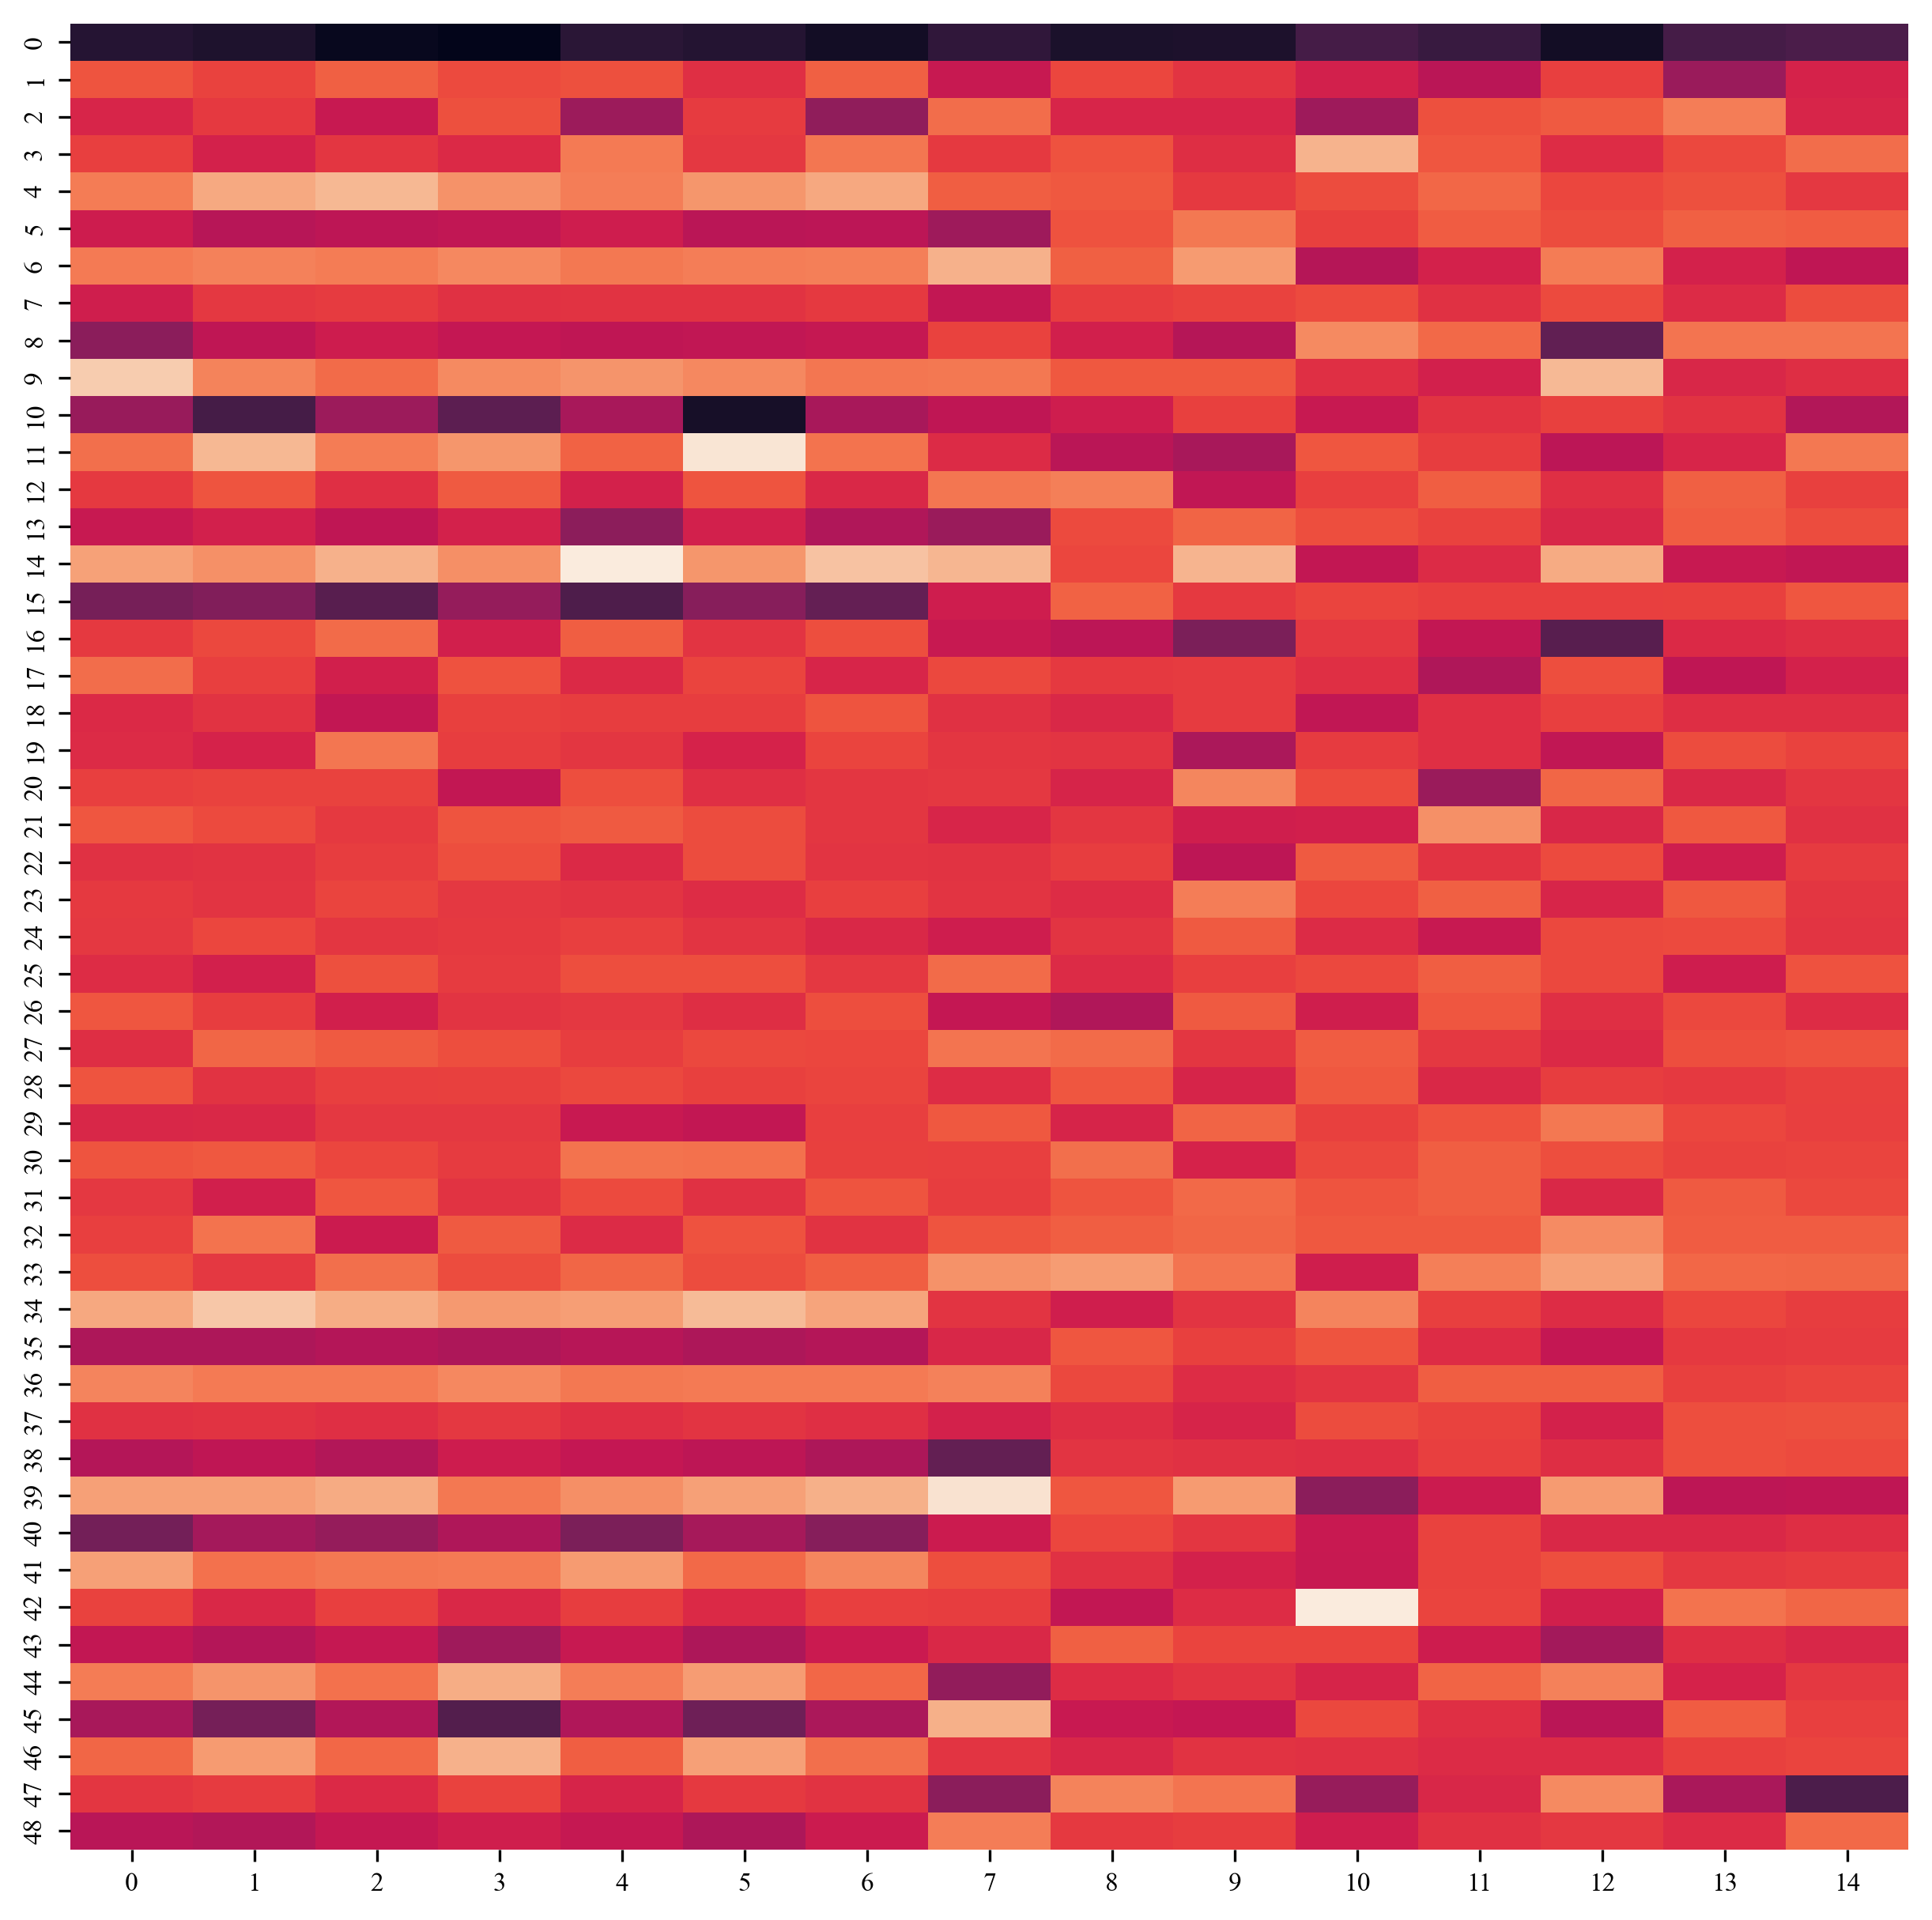

In [17]:
# Generate channel independent spectrogram.
chan_ind_spec = spec[:,1:]/spec[:,:-1]    

# Take the logarithm of the magnitude.      
chan_ind_spec_amp = np.log10(np.abs(chan_ind_spec)**2)

plt.figure(figsize=(10, 10), dpi=300)
sea.heatmap(chan_ind_spec_amp.squeeze(), cbar=False)